In [1]:
import data_funcs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb
import sklearn.preprocessing 
import pandas as pd
import shelve

## Explore original data distribution

In [2]:
drug_data, landmark_genes = data_funcs.read_drug_data()
rnaseq_dis_data, marray_dis_data = data_funcs.read_dis_data(landmark_genes)

In [3]:
print(drug_data.shape)
print(rnaseq_dis_data.shape)
print(marray_dis_data.shape)

(978, 6989)
(978, 167)
(978, 52)


In [7]:
# check for missing values, outliers in the data
print("Drug data dimension: ",drug_data.shape) # no missing values
print("RNAseq disease data dimension: " ,rnaseq_dis_data.shape)
print("Microarray disease data dimension: " ,marray_dis_data.shape)

print(drug_data.isnull().sum().sum())
print(rnaseq_dis_data.isnull().sum()) # check which genes?
print(marray_dis_data.isnull().sum())  # check which genes?


Drug data dimension:  (978, 6989)
RNAseq disease data dimension:  (978, 167)
Microarray disease data dimension:  (978, 52)
0
Disease Samples
GSM1646957    3
GSM1646961    3
GSM1646975    3
GSM1646980    3
GSM1647012    3
             ..
GSM3071051    3
GSM3071053    3
GSM3071055    3
GSM3071057    3
GSM3071059    3
Length: 167, dtype: int64
Disease Samples
GSM484450      3
GSM484453      3
GSM484454      3
GSM484457      3
GSM484462      3
GSM484477      3
GSM484479      3
GSM409137     48
GSM409138     48
GSM409139     48
GSM4147990     1
GSM4147991     1
GSM4147992     1
GSM4147993     1
GSM4147994     1
GSM4147995     1
GSM4147996     1
GSM4147997     1
GSM4147998     1
GSM4147999     1
GSM4148000     1
GSM4148001     1
GSM4148002     1
GSM4148003     1
GSM1327541    48
GSM1327542    48
GSM1327544    48
GSM1327546    48
GSM1327549    48
GSM1327550    48
GSM435905     55
GSM435906     55
GSM435907     55
GSM435908     55
GSM484603      2
GSM484604      2
GSM484612      2
GSM484613   

Text(0.5, 1.0, 'RNAseq Disease Data (ACHS4 -- all samps)')

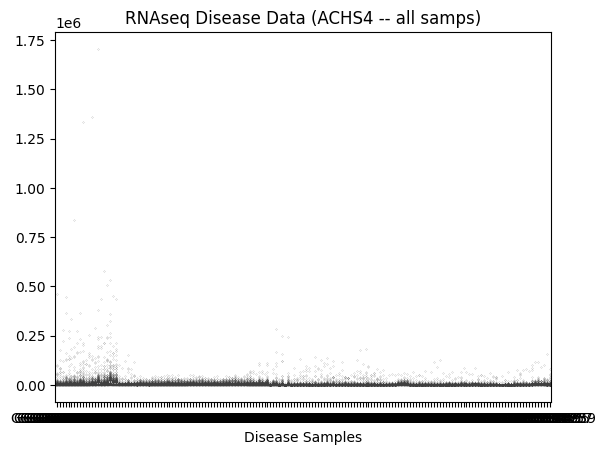

In [8]:
rnaseq_dis_subdata = rnaseq_dis_data.sample(n=15, random_state=1, axis=1)
rnaseq_dis_array = np.array(rnaseq_dis_subdata)
rnaseq_dis_array.shape
sb.boxplot(rnaseq_dis_data, fliersize = 0.1).set_title('RNAseq Disease Data (ACHS4 -- all samps)')

Text(0.5, 1.0, 'Microarray Disease Data (refine.bio) -- all samps')

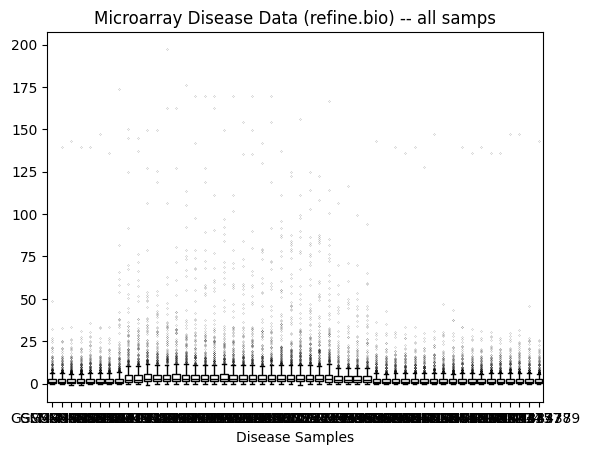

In [9]:
marray_dis_subdata = marray_dis_data.sample(n=15, random_state=1, axis=1)
sb.boxplot(marray_dis_data, fliersize = 0.1, fill = True, color = "white", linecolor = "black").set_title('Microarray Disease Data (refine.bio) -- all samps')


Text(0.5, 1.0, 'Drug Control Samples (LINCS) -- 100 samps')

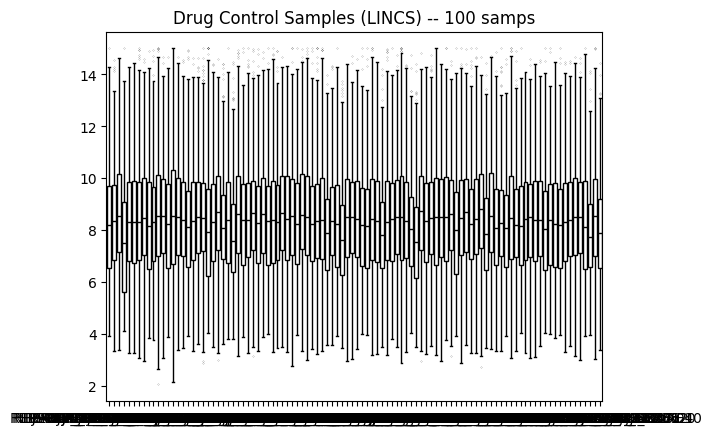

In [10]:

drug_subdata = drug_data.sample(n=100, random_state=1, axis=1)
sb.boxplot(drug_subdata, fliersize = 0.1, fill = True, color = "white", linecolor = "black").set_title('Drug Control Samples (LINCS) -- 100 samps')

Text(0.5, 1.0, 'Drug Control Samples (LINCS) – 100 random samples')

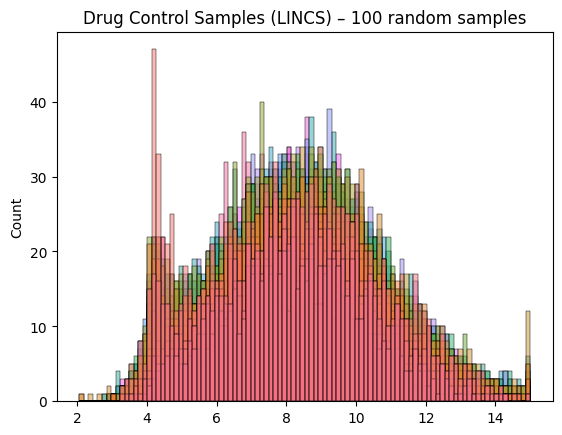

In [11]:
sb.histplot(drug_subdata, bins=100, legend = False).set_title('Drug Control Samples (LINCS) – 100 random samples')

### Plot medians of drug samples

<Axes: ylabel='Count'>

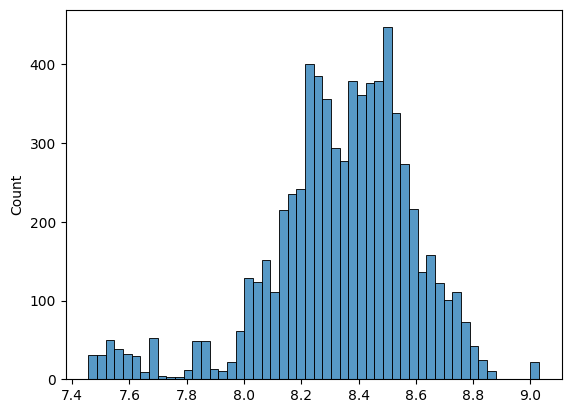

In [12]:
drug_median_vec = drug_data.median(axis=0, skipna=True)
sb.histplot(drug_median_vec)

<Axes: >

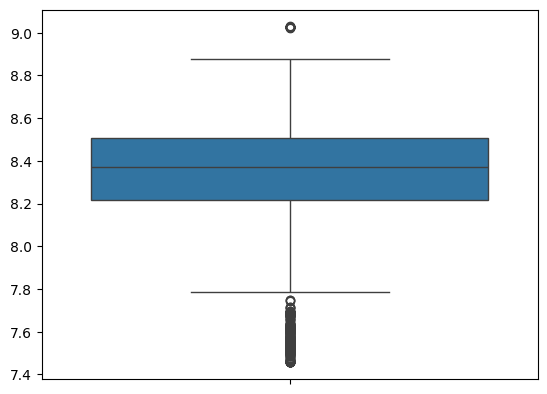

In [13]:
sb.boxplot(drug_median_vec)

# Get drug target vector
## Quantile Normalization

In [4]:
# https://github.com/ShawnLYU/Quantile_Normalize/blob/master/quantile_norm.py
def quantileNormalize(df_input):
    df = df_input.copy()
    #compute rank
    dic = {}
    for col in df:
        dic.update({col : sorted(df[col])})
    sorted_df = pd.DataFrame(dic)
    rank = sorted_df.mean(axis = 1).tolist()
    #sort
    for col in df:
        t = np.searchsorted(np.sort(df[col]), df[col])
        df[col] = [rank[i] for i in t]
    return df

/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future versi

Text(0.5, 1.0, 'QN Drug Control Samples (LINCS)')

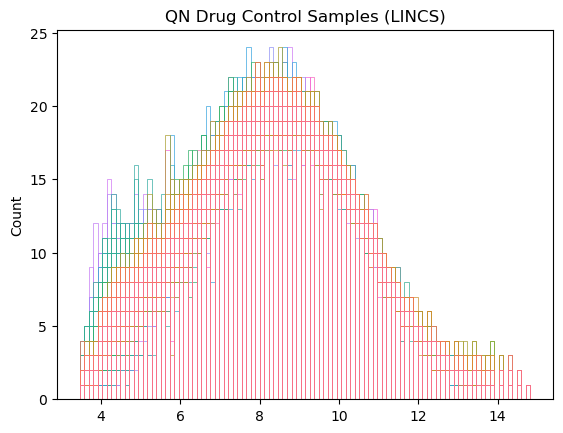

In [5]:
# perform quantile normalization and sanity check on the drug control samples
drug_data_qn = quantileNormalize(drug_data)
sb.histplot(drug_data_qn, bins=100, legend = False, fill=False).set_title('QN Drug Control Samples (LINCS)')

/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

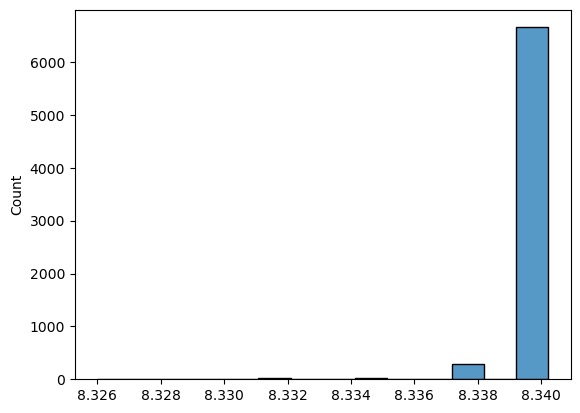

In [6]:
drugqn_median_vec = drug_data_qn.median(axis=0, skipna=True)
sb.histplot(drugqn_median_vec)

/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


<Axes: >

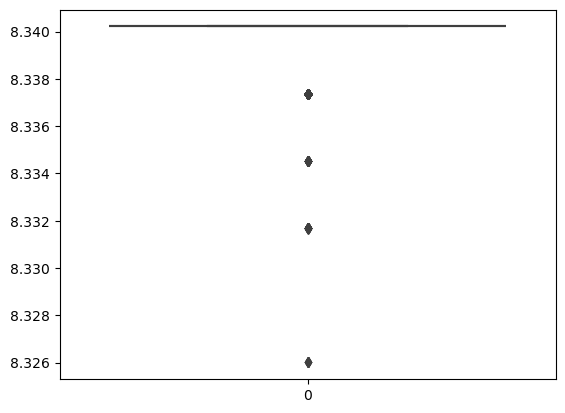

In [7]:
sb.boxplot(drugqn_median_vec)

In [25]:
# randomly sample 1 vector (1 drug signature that is quantile normalized) then use it as a target vector
# the target vector will be used to gtransform the disease data (both microarray and RNAseq)
qndrug_target_vec = drug_data_qn.sample(axis='columns', random_state=1) 
qndrug_target_vec

,REP.A007_PC3_24H_B22:J13
rid,
5720,9.413179
466,5.075606
6009,9.947058
2309,6.303096
387,6.762878
...,...
23200,9.039375
51293,11.666260
10962,9.705717


/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future versi

<Axes: ylabel='Count'>

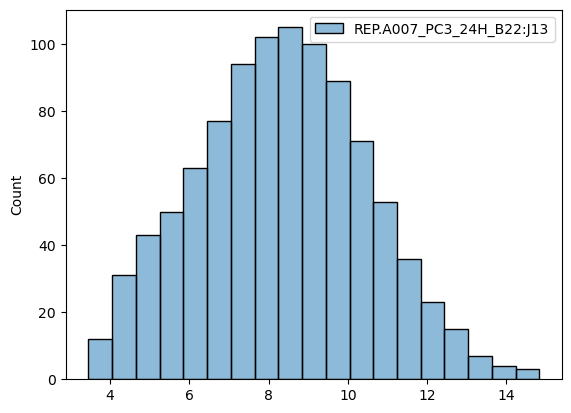

In [12]:
sb.histplot(qndrug_target_vec)

In [13]:
with shelve.open('qn_drug_lv3data') as qn_drug_lv3data:
    qn_drug_lv3data['drug_data_qn'] = drug_data_qn
    qn_drug_lv3data['qndrug_target_vec'] = qndrug_target_vec
qn_drug_lv3data.close()      

In [17]:
drug_data_qn

,LJP005_A375_24H_B19:A03,LJP005_A375_24H_B19:A04,LJP005_A375_24H_B19:A05,LJP005_A375_24H_B19:A06,LJP005_A375_24H_B19:B03,LJP005_A375_24H_B19:B04,LJP005_A375_24H_B19:B05,LJP005_A375_24H_B19:B06,LJP005_A375_24H_B19:F07,LJP005_A375_24H_B19:F08,...,REP.A028_YAPC_24H_B25:F09,REP.A028_YAPC_24H_B25:F10,REP.A028_YAPC_24H_B25:F11,REP.A028_YAPC_24H_B25:F12,REP.A028_YAPC_24H_B25:J13,REP.A028_YAPC_24H_B25:J14,REP.A028_YAPC_24H_B25:J15,REP.A028_YAPC_24H_B25:J16,REP.A028_YAPC_24H_B25:J17,REP.A028_YAPC_24H_B25:J18
rid,,,,,,,,,,,,,,,,,,,,,
5720,11.543965,11.510558,11.430315,11.266377,11.543965,11.612832,11.577747,11.238309,11.169989,11.494523,...,13.278962,13.278962,13.533735,13.441488,13.144819,13.634435,13.441488,13.441488,13.441488,13.441488
466,7.645389,7.699559,7.486614,7.474133,7.590786,7.505121,7.952670,7.735502,7.548140,7.675566,...,7.765098,7.917945,7.776995,7.806839,7.303048,7.741477,7.923720,8.102007,7.836218,7.681595
6009,11.527134,11.543965,11.779896,11.860454,11.595319,11.839470,11.722370,11.741305,11.722370,11.543965,...,11.881306,11.902598,11.779896,11.924068,12.116607,11.902598,11.946233,12.040367,12.090492,11.760431
2309,5.753854,5.570784,6.154816,5.775626,5.731591,5.893603,5.808799,5.709201,6.116086,5.742762,...,6.097205,6.125775,6.970357,6.087066,5.570784,6.145348,6.338715,6.570608,6.266413,6.636563
387,9.580054,9.560438,9.495424,9.307379,9.086409,9.109910,9.553888,9.813962,9.469902,9.508277,...,6.991777,6.266413,6.770671,6.461225,7.753266,6.660781,6.770671,6.861566,6.905522,6.762878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,8.148063,8.761851,8.560743,8.440268,8.234051,8.388929,8.268478,7.935326,8.079095,8.016018,...,9.356874,8.911562,9.793360,9.121709,9.444289,9.732703,9.127682,9.363059,9.180881,9.139406
51293,10.928015,11.032125,10.996768,10.062768,10.123030,9.820832,10.996768,11.105411,11.092983,10.026059,...,9.489019,9.204566,9.319812,9.015918,10.356514,9.679003,8.957925,9.612747,9.692300,9.705717
10962,11.043982,11.461961,11.032125,12.731211,11.527134,10.928015,11.043982,11.309150,11.197058,10.679184,...,5.245558,9.313596,7.492798,9.240375,6.294092,11.860454,7.277054,7.411462,5.128469,7.360941


In [3]:
# read in saved qn drug data variables
qn_drug_lv3data = shelve.open("../data/expression/drug_data/qn_drug_lv3data") 
qndrug_target_vec_ = qn_drug_lv3data['qndrug_target_vec']
drug_data_qn_ = qn_drug_lv3data['drug_data_qn']

In [4]:
drug_data_qn_

,LJP005_A375_24H_B19:A03,LJP005_A375_24H_B19:A04,LJP005_A375_24H_B19:A05,LJP005_A375_24H_B19:A06,LJP005_A375_24H_B19:B03,LJP005_A375_24H_B19:B04,LJP005_A375_24H_B19:B05,LJP005_A375_24H_B19:B06,LJP005_A375_24H_B19:F07,LJP005_A375_24H_B19:F08,...,REP.A028_YAPC_24H_B25:F09,REP.A028_YAPC_24H_B25:F10,REP.A028_YAPC_24H_B25:F11,REP.A028_YAPC_24H_B25:F12,REP.A028_YAPC_24H_B25:J13,REP.A028_YAPC_24H_B25:J14,REP.A028_YAPC_24H_B25:J15,REP.A028_YAPC_24H_B25:J16,REP.A028_YAPC_24H_B25:J17,REP.A028_YAPC_24H_B25:J18
rid,,,,,,,,,,,,,,,,,,,,,
5720,11.543965,11.510558,11.430315,11.266377,11.543965,11.612832,11.577747,11.238309,11.169989,11.494523,...,13.278962,13.278962,13.533735,13.441488,13.144819,13.634435,13.441488,13.441488,13.441488,13.441488
466,7.645389,7.699559,7.486614,7.474133,7.590786,7.505121,7.952670,7.735502,7.548140,7.675566,...,7.765098,7.917945,7.776995,7.806839,7.303048,7.741477,7.923720,8.102007,7.836218,7.681595
6009,11.527134,11.543965,11.779896,11.860454,11.595319,11.839470,11.722370,11.741305,11.722370,11.543965,...,11.881306,11.902598,11.779896,11.924068,12.116607,11.902598,11.946233,12.040367,12.090492,11.760431
2309,5.753854,5.570784,6.154816,5.775626,5.731591,5.893603,5.808799,5.709201,6.116086,5.742762,...,6.097205,6.125775,6.970357,6.087066,5.570784,6.145348,6.338715,6.570608,6.266413,6.636563
387,9.580054,9.560438,9.495424,9.307379,9.086409,9.109910,9.553888,9.813962,9.469902,9.508277,...,6.991777,6.266413,6.770671,6.461225,7.753266,6.660781,6.770671,6.861566,6.905522,6.762878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,8.148063,8.761851,8.560743,8.440268,8.234051,8.388929,8.268478,7.935326,8.079095,8.016018,...,9.356874,8.911562,9.793360,9.121709,9.444289,9.732703,9.127682,9.363059,9.180881,9.139406
51293,10.928015,11.032125,10.996768,10.062768,10.123030,9.820832,10.996768,11.105411,11.092983,10.026059,...,9.489019,9.204566,9.319812,9.015918,10.356514,9.679003,8.957925,9.612747,9.692300,9.705717
10962,11.043982,11.461961,11.032125,12.731211,11.527134,10.928015,11.043982,11.309150,11.197058,10.679184,...,5.245558,9.313596,7.492798,9.240375,6.294092,11.860454,7.277054,7.411462,5.128469,7.360941


In [5]:
qndrug_target_vec_

,REP.A007_PC3_24H_B22:J13
rid,
5720,9.413179
466,5.075606
6009,9.947058
2309,6.303096
387,6.762878
...,...
23200,9.039375
51293,11.666260
10962,9.705717


In [19]:
# perform quantile normalization on the disease data from the target vector
def qnorm_dis_data(dis_data, target_vec):
    dis_data_qn = dis_data.copy()
    target_vec = np.sort(np.array(target_vec))
    for col in dis_data_qn.columns:
        t = np.searchsorted(np.sort(dis_data[col]), dis_data[col])
        dis_data_qn.loc[:,col] = [target_vec[i] for i in t]
    return dis_data_qn.astype('float64')

rnaseq_dis_data_qn = qnorm_dis_data(rnaseq_dis_data, qndrug_target_vec_)

In [20]:
rnaseq_dis_data

Disease Samples,GSM1646957,GSM1646961,GSM1646975,GSM1646980,GSM1647012,GSM1647013,GSM1647024,GSM1647025,GSM1647037,GSM1647038,...,GSM3071041,GSM3071043,GSM3071045,GSM3071047,GSM3071049,GSM3071051,GSM3071053,GSM3071055,GSM3071057,GSM3071059
GeneID,,,,,,,,,,,,,,,,,,,,,
5720,3655.0,3883.0,2643.0,5939.0,3946.0,4030.0,4454.0,3611.0,3965.0,8974.0,...,3139.0,2522.0,2943.0,3851.0,5989.0,9935.0,5739.0,6592.0,6031.0,2558.0
466,469.0,264.0,43.0,308.0,278.0,186.0,547.0,178.0,705.0,482.0,...,75.0,129.0,172.0,201.0,1.0,602.0,134.0,334.0,470.0,161.0
6009,2440.0,1327.0,477.0,2058.0,1722.0,1337.0,2488.0,1165.0,4919.0,4911.0,...,407.0,399.0,198.0,1324.0,607.0,775.0,824.0,1056.0,440.0,1176.0
2309,468.0,384.0,307.0,1402.0,589.0,387.0,1403.0,521.0,1701.0,951.0,...,754.0,956.0,710.0,1257.0,1862.0,441.0,878.0,1418.0,34.0,932.0
387,18864.0,13572.0,8881.0,28555.0,25826.0,19150.0,40113.0,17866.0,30022.0,36181.0,...,8109.0,6683.0,5808.0,12342.0,8428.0,12527.0,6013.0,10328.0,9867.0,9269.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,672.0,320.0,151.0,791.0,696.0,352.0,1064.0,277.0,2501.0,1126.0,...,591.0,747.0,596.0,598.0,2215.0,26.0,1054.0,1636.0,310.0,374.0
51293,130.0,205.0,515.0,355.0,207.0,679.0,821.0,668.0,210.0,561.0,...,62.0,120.0,177.0,188.0,137.0,824.0,793.0,358.0,411.0,158.0
10962,68.0,41.0,3.0,42.0,59.0,34.0,59.0,22.0,50.0,94.0,...,0.0,57.0,42.0,20.0,3.0,1.0,0.0,73.0,0.0,23.0


In [21]:
rnaseq_dis_data_qn.astype(float)

Disease Samples,GSM1646957,GSM1646961,GSM1646975,GSM1646980,GSM1647012,GSM1647013,GSM1647024,GSM1647025,GSM1647037,GSM1647038,...,GSM3071041,GSM3071043,GSM3071045,GSM3071047,GSM3071049,GSM3071051,GSM3071053,GSM3071055,GSM3071057,GSM3071059
GeneID,,,,,,,,,,,,,,,,,,,,,
5720,7.859802,8.537667,8.853525,9.645474,6.067530,7.164153,7.789019,9.672145,9.954167,9.175050,...,11.368449,7.386210,7.455291,5.640947,8.365837,11.156864,9.699036,8.365837,7.554237,7.150708
466,8.148063,7.309459,4.911186,8.383166,7.865655,7.753266,8.744574,5.088866,7.430205,11.169989,...,7.681595,9.848772,8.170982,12.065384,5.698028,9.246511,9.658775,12.505475,8.142290,11.445980
6009,5.956626,6.934542,10.547733,7.486614,7.486614,8.543443,6.770671,7.103170,9.911662,8.698447,...,7.486614,9.074663,10.390301,7.789019,8.905826,9.068777,8.813315,7.824543,9.163264,5.956626
2309,10.862269,6.512516,12.311494,10.511670,10.905776,12.225094,7.061935,8.555062,10.364922,7.474133,...,8.595201,7.211528,8.715676,6.636563,8.600923,8.617872,8.377349,8.119439,6.948927,6.660781
387,9.450683,9.521292,8.360153,7.027198,9.450683,7.137200,10.538628,9.294982,6.890938,9.294982,...,10.708801,8.721431,10.708801,8.721431,8.182459,7.137200,8.486135,9.294982,7.442728,6.890938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,13.022956,9.665292,11.414669,8.148063,9.933032,8.503296,10.055349,8.262721,10.689105,8.303158,...,8.033164,10.699088,7.812715,6.927404,11.294587,10.485074,8.629138,10.208624,8.905826,11.080545
51293,5.675376,11.703412,9.264417,10.216754,4.824551,10.819824,11.210580,9.092359,11.280347,11.969601,...,8.744574,8.303158,8.297389,10.424278,9.051077,5.997739,11.020285,11.309150,6.417993,8.681065
10962,4.281032,5.522732,11.068174,4.656175,5.862452,5.987489,5.582620,4.504443,5.914713,6.338715,...,9.413179,13.748695,6.963305,5.154787,8.744574,4.521934,9.413179,6.504160,9.413179,7.669598


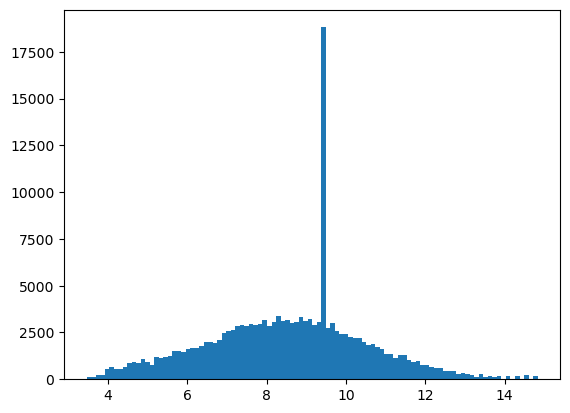

In [28]:
plt.hist(rnaseq_dis_data_qn.values.flatten(), bins=100),
plt.show()